In [3]:
1 #setup · PY
# ============================================================
#  TELECOM CUSTOMER CHURN ANALYSIS
#  Phase 1 — Environment Setup & Data Loading
#  Dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv
# ============================================================
 
# ── STEP 1: Import Libraries ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 5)
 
print("✅ All libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")
 

✅ All libraries imported successfully
   pandas  2.3.3
   numpy   2.3.5
   seaborn 0.13.2


In [4]:
 #── STEP 2: Load Dataset ─────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
 
print("\n✅ Dataset loaded")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")


✅ Dataset loaded
   Rows    : 7,043
   Columns : 21


In [5]:
# ── STEP 3: First Look ───────────────────────────────────────
print("\n── First 5 rows ──────────────────────────────────────")
print(df.head())
 
print("\n── Column data types ─────────────────────────────────")
print(df.dtypes.to_string())


── First 5 rows ──────────────────────────────────────
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  Tech

In [6]:
# ── STEP 4: Identify the TotalCharges Problem ────────────────
print("\n── Checking TotalCharges ─────────────────────────────")
print(f"  dtype before fix : {df['TotalCharges'].dtype}")
 
# These 11 rows have tenure=0 and blank TotalCharges (new customers)
problem_rows = df[df['TotalCharges'].str.strip() == '']
print(f"  Blank rows found : {len(problem_rows)}")
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])


── Checking TotalCharges ─────────────────────────────
  dtype before fix : object
  Blank rows found : 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [7]:
# ── STEP 5: Fix TotalCharges ─────────────────────────────────
# Convert to numeric — blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
 
# Fill NaN with median (safe for skewed distributions)
median_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_charges)
 
print(f"\n✅ TotalCharges fixed")
print(f"   dtype after fix  : {df['TotalCharges'].dtype}")
print(f"   Nulls remaining  : {df['TotalCharges'].isnull().sum()}")
print(f"   Median used      : ${median_charges:,.2f}")


✅ TotalCharges fixed
   dtype after fix  : float64
   Nulls remaining  : 0
   Median used      : $1,397.47


In [8]:
# ── STEP 6: Verify No Missing Values Remain ──────────────────
print("\n── Missing value check ───────────────────────────────")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values — dataset is fully clean!")
else:
    print(missing[missing > 0])
 


── Missing value check ───────────────────────────────
  ✅ No missing values — dataset is fully clean!


In [9]:
# ── STEP 7: Categorical Columns Overview ─────────────────────
print("\n── Unique values per categorical column ──────────────")
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')   # skip the ID column
 
for col in cat_cols:
    vals = df[col].unique().tolist()
    print(f"  {col:<20} → {vals}")


── Unique values per categorical column ──────────────
  gender               → ['Female', 'Male']
  Partner              → ['Yes', 'No']
  Dependents           → ['No', 'Yes']
  PhoneService         → ['No', 'Yes']
  MultipleLines        → ['No phone service', 'No', 'Yes']
  InternetService      → ['DSL', 'Fiber optic', 'No']
  OnlineSecurity       → ['No', 'Yes', 'No internet service']
  OnlineBackup         → ['Yes', 'No', 'No internet service']
  DeviceProtection     → ['No', 'Yes', 'No internet service']
  TechSupport          → ['No', 'Yes', 'No internet service']
  StreamingTV          → ['No', 'Yes', 'No internet service']
  StreamingMovies      → ['No', 'Yes', 'No internet service']
  Contract             → ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling     → ['Yes', 'No']
  PaymentMethod        → ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
  Churn                → ['No', 'Yes']


In [10]:
# ── STEP 8: Numeric Summary ──────────────────────────────────
print("\n── Numeric columns summary ───────────────────────────")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))
 


── Numeric columns summary ───────────────────────────
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2281.92
std      24.56           30.09       2265.27
min       0.00           18.25         18.80
25%       9.00           35.50        402.22
50%      29.00           70.35       1397.48
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


In [11]:
# ── STEP 9: Churn Distribution ───────────────────────────────
print("\n── Churn distribution ────────────────────────────────")
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
print(f"  No  (retained) : {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Yes (churned)  : {churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)")


── Churn distribution ────────────────────────────────
  No  (retained) : 5,174  (73.5%)
  Yes (churned)  : 1,869  (26.5%)


Text(0.5, 1.0, 'Churn Distribution')

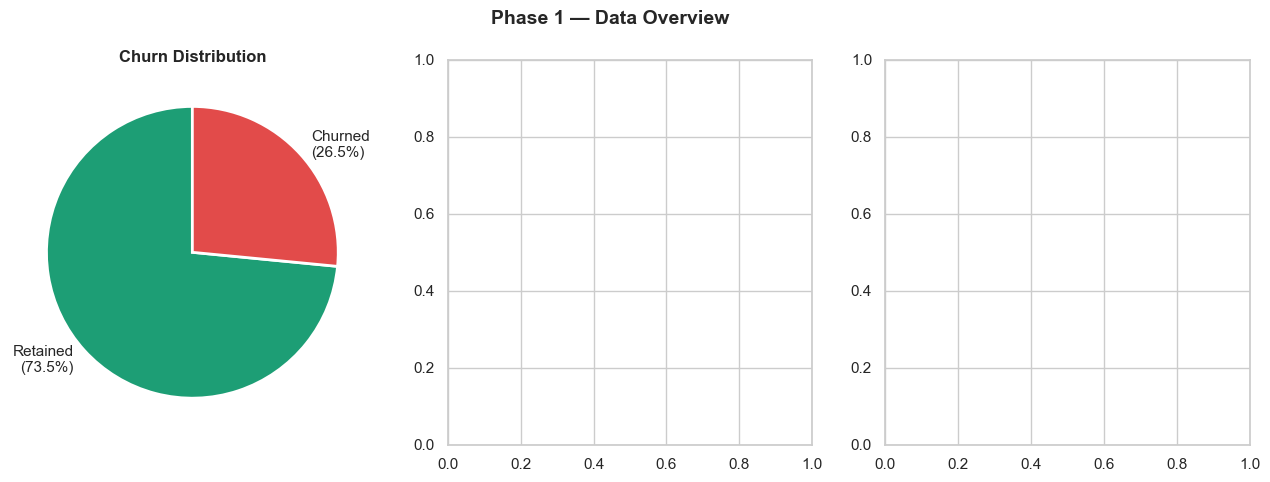

In [12]:
# ── STEP 10: Quick Visualisations ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 1 — Data Overview', fontsize=14, fontweight='bold')
 
# Plot 1: Churn pie chart
axes[0].pie(
    churn_counts,
    labels=['Retained\n(73.5%)', 'Churned\n(26.5%)'],
    colors=['#1D9E75', '#E24B4A'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Churn Distribution', fontweight='bold')

In [13]:
 #Plot 2: Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={'No': '#1D9E75', 'Yes': '#E24B4A'},
             ax=axes[1], alpha=0.7)
axes[1].set_title('Tenure by Churn Status', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')

Text(0.5, 4.444444444444445, 'Tenure (months)')

In [14]:
# Plot 3: Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30,
             palette={'No': '#1D9E75', 'Yes': '#E24B4A'},
             ax=axes[2], alpha=0.7)
axes[2].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[2].set_xlabel('Monthly Charges ($)')
 
plt.tight_layout()
plt.savefig('phase1_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Chart saved as phase1_overview.png")
 

<Figure size 800x500 with 0 Axes>


✅ Chart saved as phase1_overview.png


In [15]:
# ── STEP 11: Save Cleaned Dataset ───────────────────────────
df.to_csv('telco_churn_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as telco_churn_cleaned.csv")
 
print("\n" + "="*55)
print("  Phase 1 complete — ready for EDA (Phase 2)")
print("="*55)
print(f"\n  Dataset shape  : {df.shape}")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Churn rate     : {churn_pct['Yes']:.1f}%")
print(f"  Avg tenure     : {df['tenure'].mean():.1f} months")
print(f"  Avg monthly $  : ${df['MonthlyCharges'].mean():.2f}")

✅ Cleaned dataset saved as telco_churn_cleaned.csv

  Phase 1 complete — ready for EDA (Phase 2)

  Dataset shape  : (7043, 21)
  Missing values : 0
  Churn rate     : 26.5%
  Avg tenure     : 32.4 months
  Avg monthly $  : $64.76
